In [2]:
import numpy as np
import os

import matplotlib.pyplot as plt

(6, 25043, 16, 3)


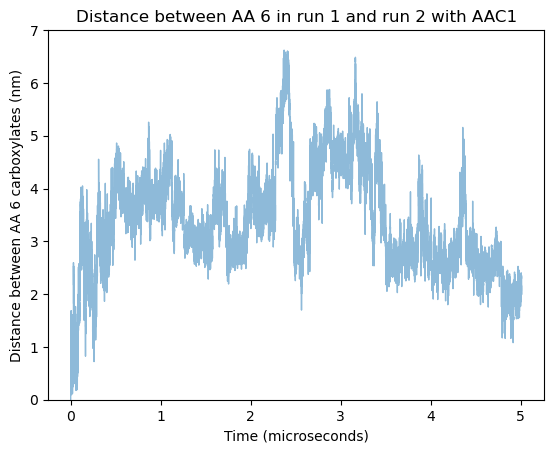

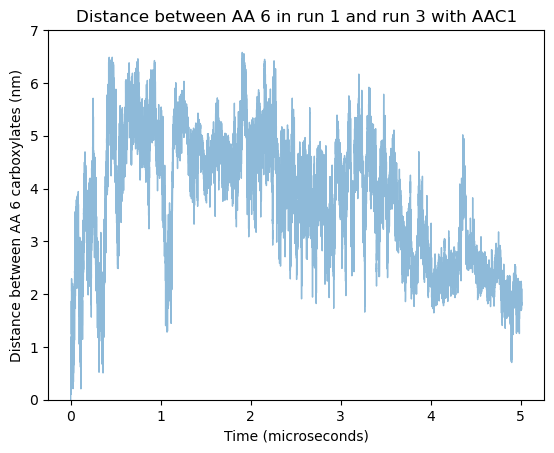

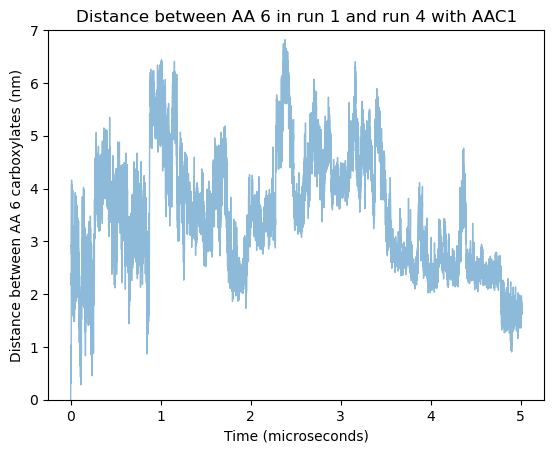

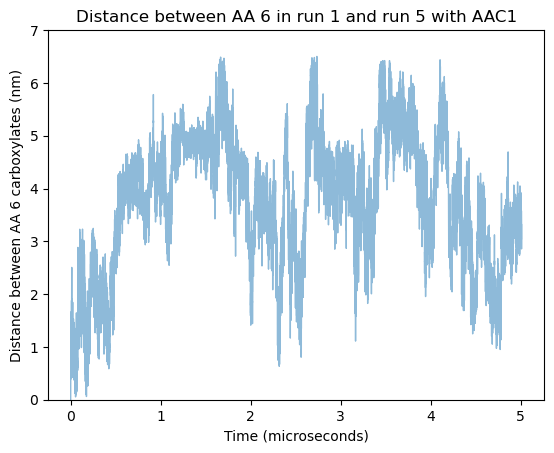

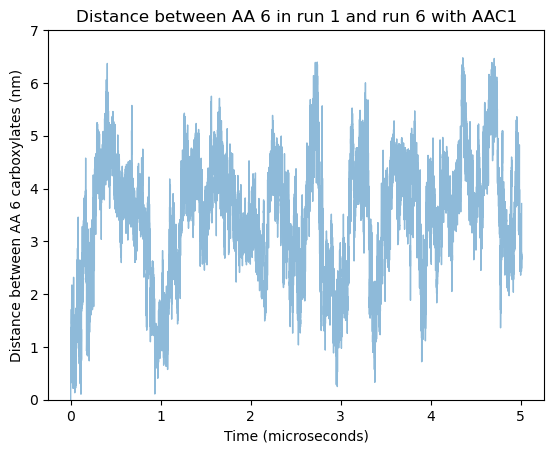

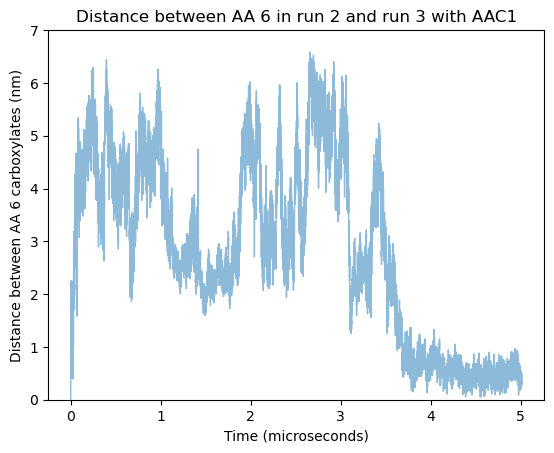

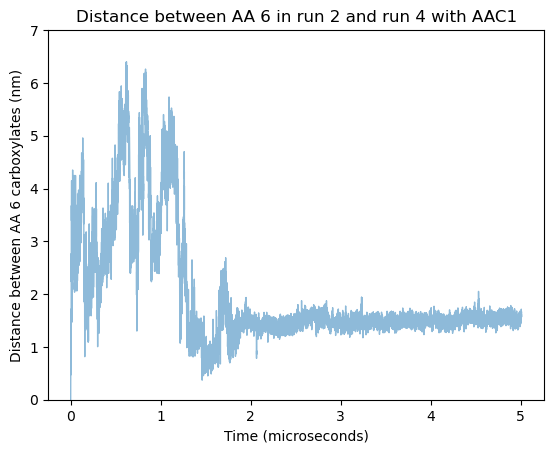

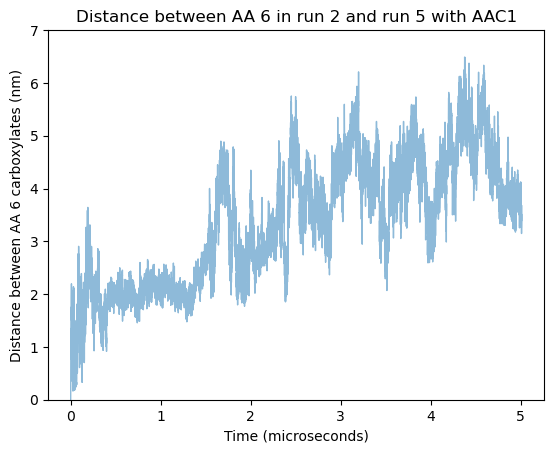

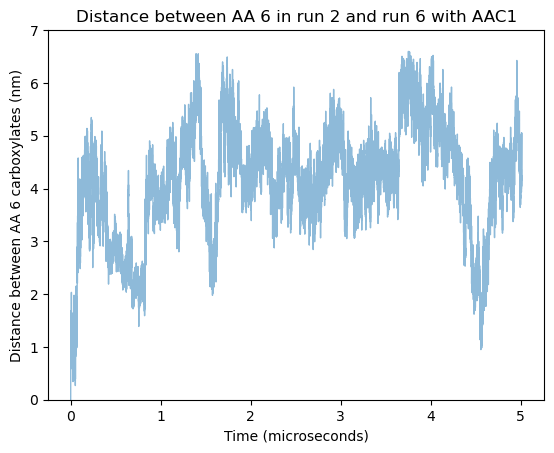

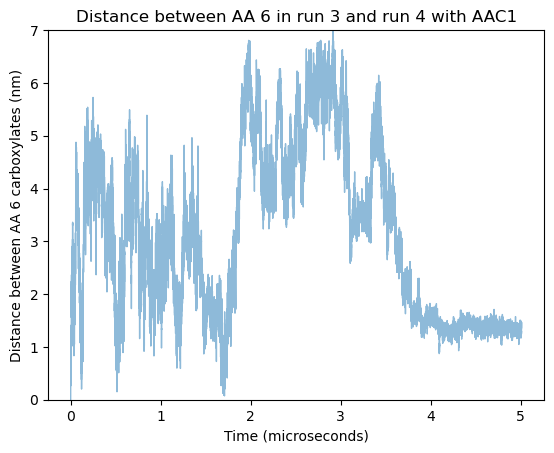

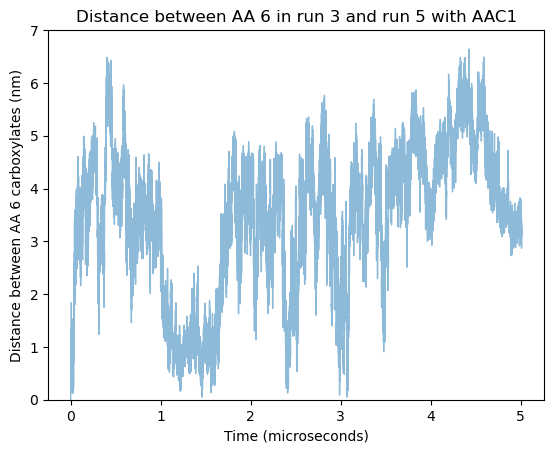

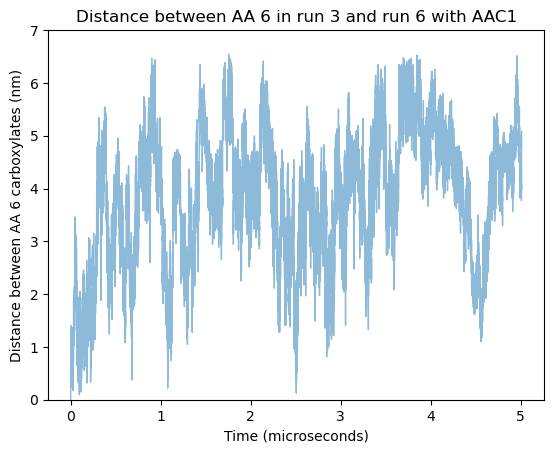

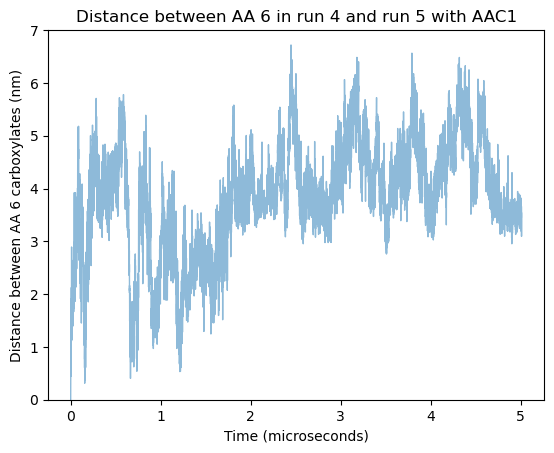

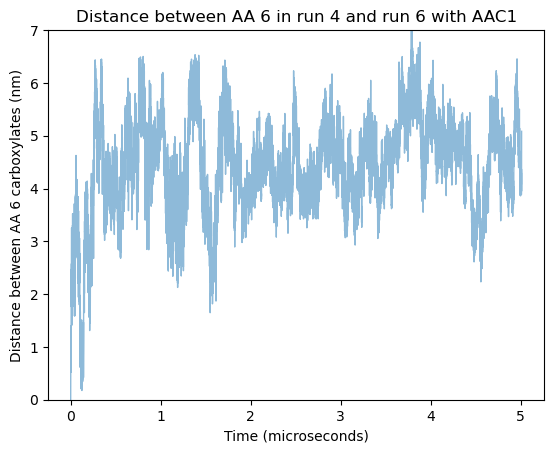

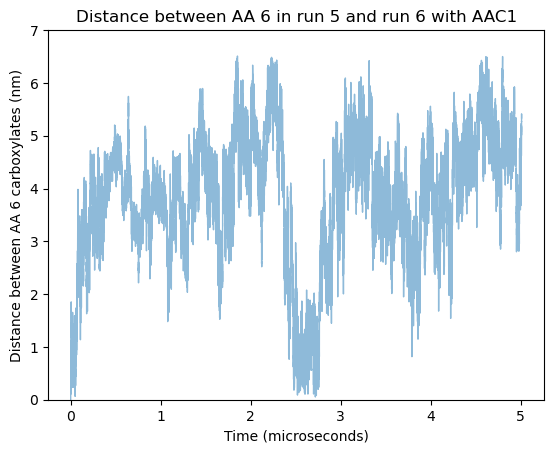

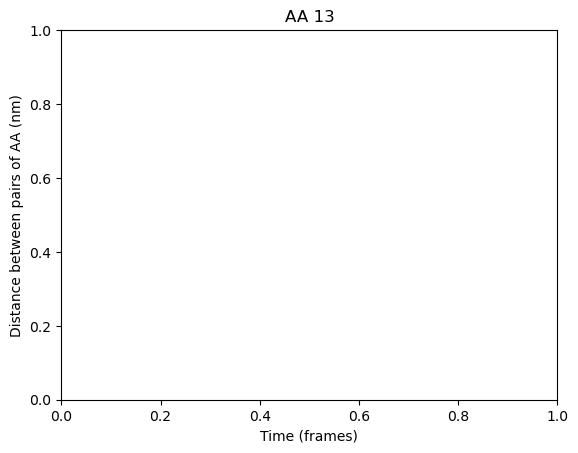

(6, 24155, 16, 3)


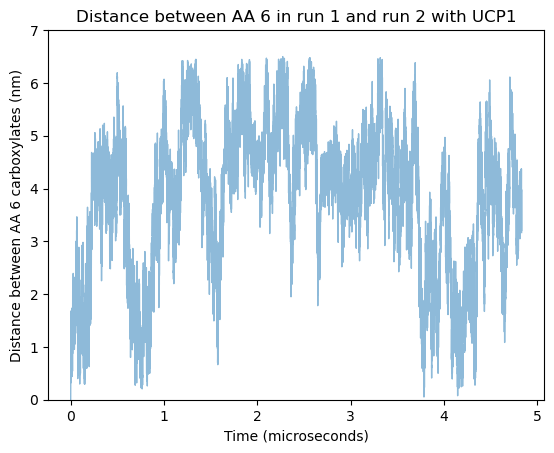

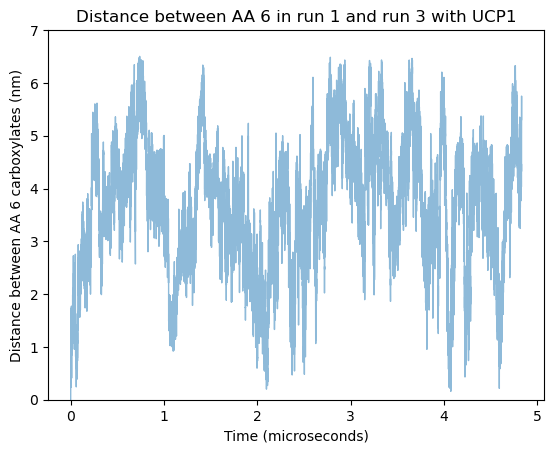

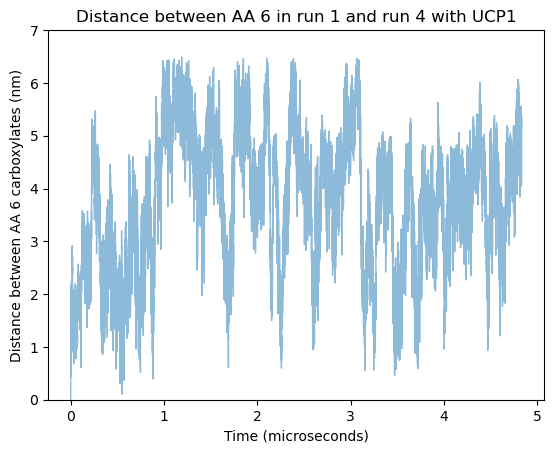

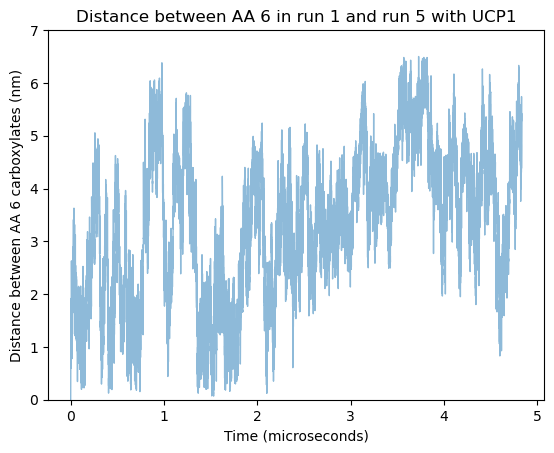

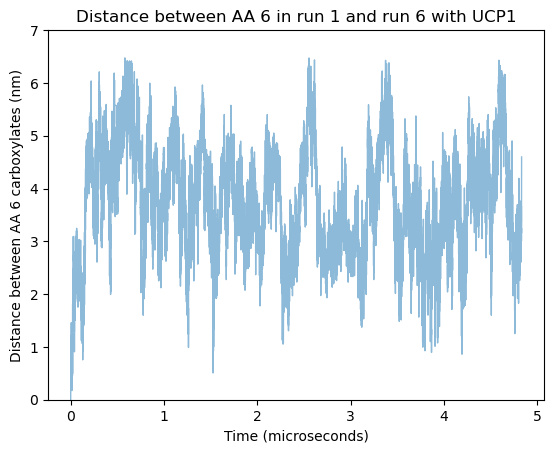

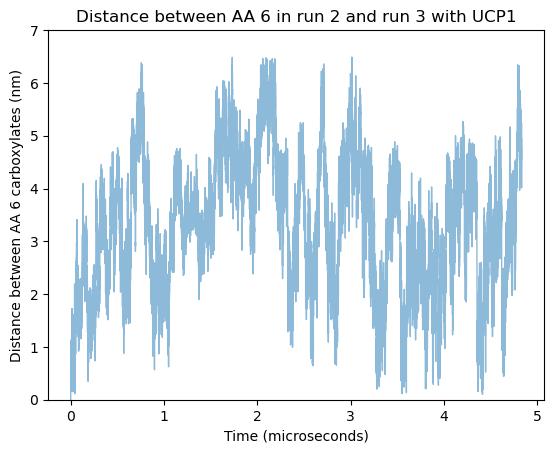

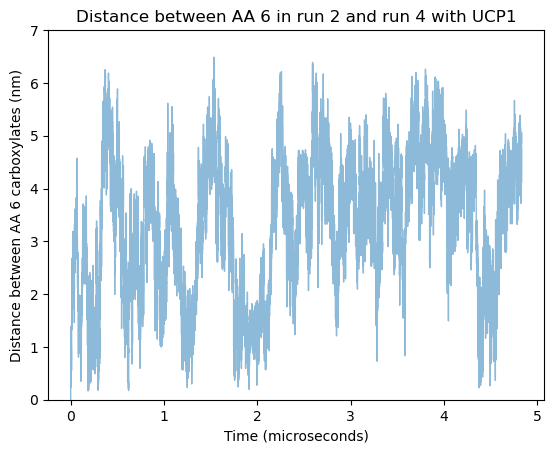

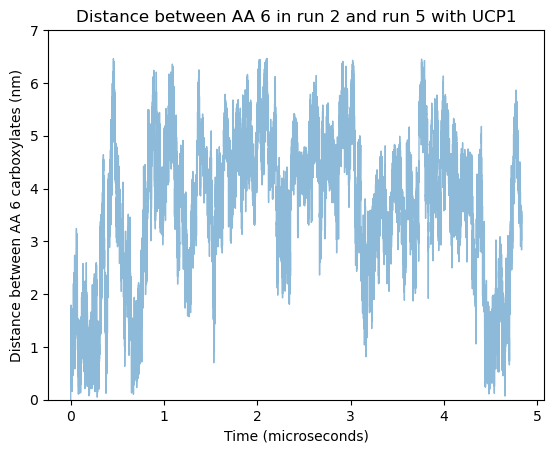

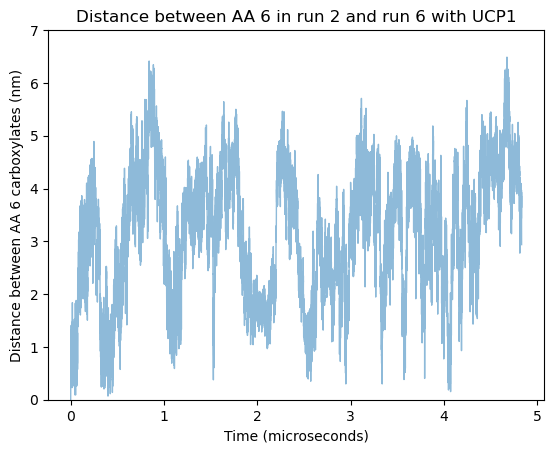

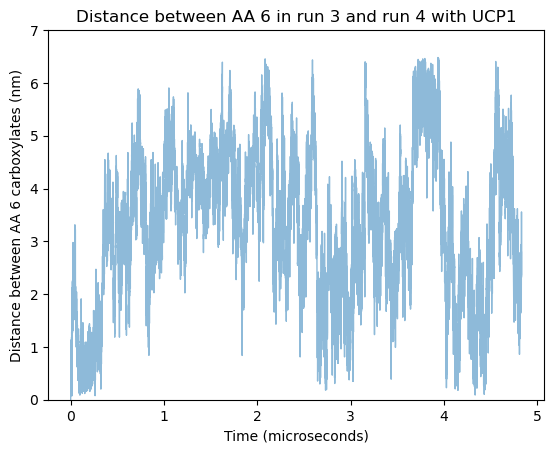

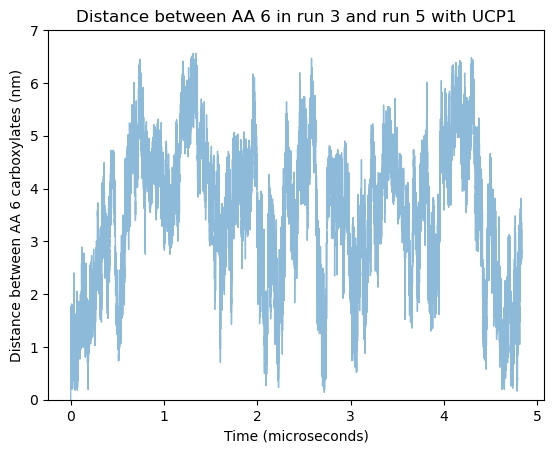

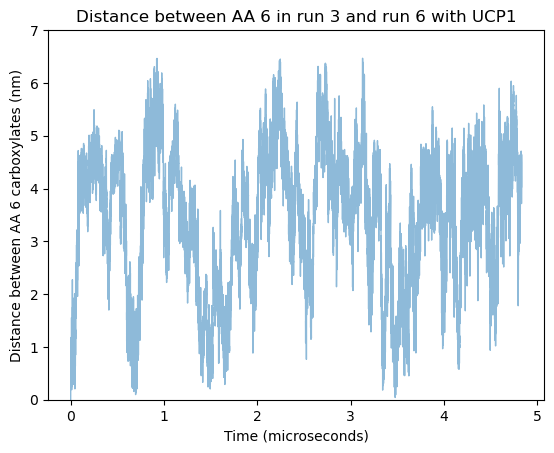

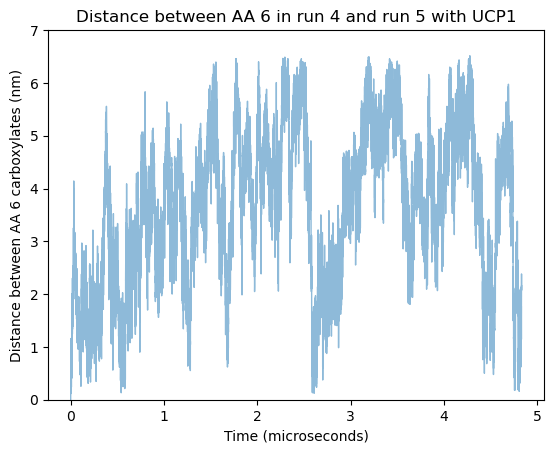

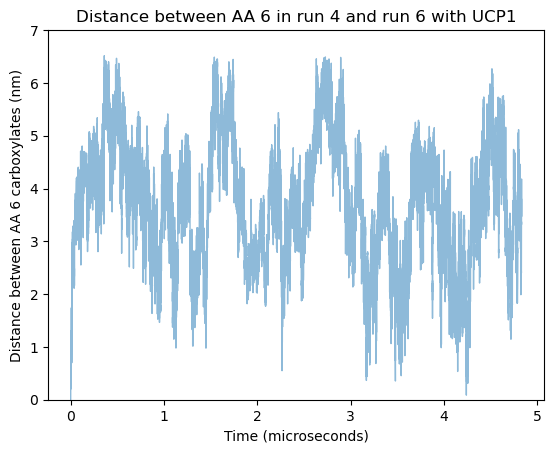

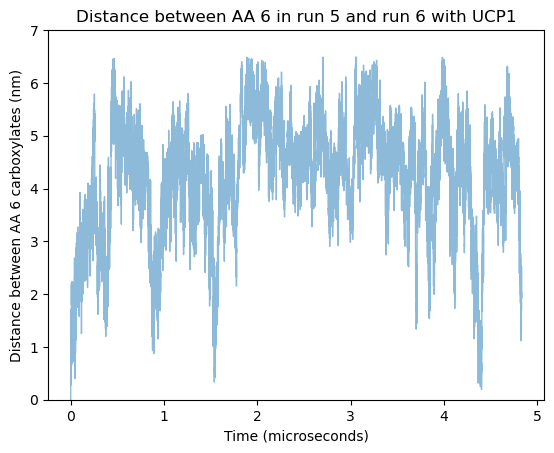

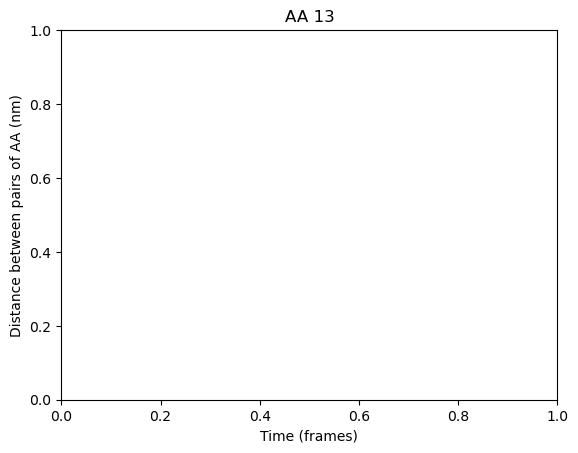

In [5]:
threshold = 0.33
window = 500

colors = ["C0", "C1", "C2", "C3", "C4", "grey"]
pdbids = {"aac1": "2C3E", "ucp1": "8HBV"}

def compile_rmsd():

    inputpath = "/home/jonathan/Documents/grabelab/aac1-ucp1/long-aac1-ucp1/aa_xyz_dist"

    servers = ["wynton", "degrabo"]
    proteins = ["aac1", "ucp1"]

    #loop over servers, proteins, and parallel runs
    for protein in proteins:

        ci = 0

        aa_xyz = []

        #plt.figure(figsize = (15,6), dpi=600)

        for server in servers:
            for run in range(1,5):
                if server == "degrabo" and run > 2:
                    continue

                #step is in microseconds per saved frame
                if server == "wynton" and (run == 3 or run == 4):
                    step = 1/10000
                    inc = 2
                else:
                    step = 1/5000
                    inc = 1

                dists = []
 
                for seg in range(1,20):

                    file = f"{inputpath}/{server}/{protein}/run0{run}/{protein}-{server}-run{str(run).zfill(2)}-seg{str(seg).zfill(2)}-aaxyz.npy"

                    if os.path.exists(file):
                        dists.append(np.load(file))

                dists = np.concatenate(dists)

                aa_xyz.append(dists[::inc]) #thanks to copilot for remembering [::inc]

                # print(dists.shape)

                # plt.plot(dists)
                # plt.show()
                # # print(dists.shape)
                # # deltas = np.max(dists, axis = 0)-np.min(dists, axis = 0)
                # # plt.hist(deltas)
                # # plt.show()

                # aa_z.append(dists.flatten()[::inc])

                # plt.show()
                ci += 1

        tmin = min(a.shape[0] for a in aa_xyz)

        aa_xyz_trimmed = [a[:tmin] for a in aa_xyz]

        aa_xyz = np.stack(aa_xyz_trimmed)
        print(aa_xyz.shape)

        plot_pairwise_distances = True
        plot_mean_run_distances = False
        plot_max_distances = False
        plot_individual = True

        dists_2us = []

        #loop over AA
        for aai in range(16):

            # dists_2us = []

            if plot_individual:
                if aai != 13:
                    continue

            # if aai != 8:
            #     continue
            
            distances_all = []

            distances_byrun = [[], [], [], [], [], []]

            for run1 in range(6):

                #plt.scatter(aa_xyz[run1,:,aai][:10000,0],aa_xyz[run1,:,aai][:10000,1], s = 1)

                for run2 in range(run1+1,6):

                    delta_r = aa_xyz[run1,:,aai]-aa_xyz[run2,:,aai]
                    delta_x_nopbc = np.abs(delta_r[:,0])
                    delta_y_nopbc = np.abs(delta_r[:,1])
                    delta_z = delta_r[:,2]

                    delta_x = np.where(delta_x_nopbc < 9.2/2, delta_x_nopbc, 9.2-delta_x_nopbc)
                    delta_y = np.where(delta_y_nopbc < 9.2/2, delta_y_nopbc, 9.2-delta_y_nopbc)

                    distances = np.sqrt(delta_x**2 + delta_y**2 + delta_z**2)

                    distances_byrun[run1].append(distances)
                    distances_byrun[run2].append(distances)

                    if plot_max_distances:
                        plt.plot(np.maximum.accumulate(distances), linewidth=1)#, alpha=0.5)
                        dists_2us.append(np.maximum.accumulate(distances)[10000])

                        if plot_individual:
                            plt.ylim(0,7)
                            plt.title(f"Distance between run {run1+1} and run {run2+1} for AA {aai-8+1} in {protein}")
                            plt.show()
                        #this is the same as the accumulate function but much slower
                        # maxdists = [max(distances[0:i]) for i in range(1, len(distances)+1)]
                        # plt.plot(maxdists, linewidth=1, linestyle='dashed')#, alpha=1)

                    if plot_pairwise_distances:
                        plt.plot([i/5000 for i in range(len(distances))], distances, linewidth=1, alpha=0.5)
                        if plot_individual:
                            plt.ylim(0,7)
                            plt.xlabel(f"Time (microseconds)")
                            plt.ylabel("Distance between AA 6 carboxylates (nm)")

                            plt.title(f"Distance between AA {aai-8+1} in run {run1+1} and run {run2+1} with {protein.upper()}")

                            if run1 == 1 and run2 == 2:
                                plt.savefig(f"{inputpath}/distance_run2_run3_aa{aai+1}_{protein}.svg", bbox_inches='tight', format ='svg')
                            plt.show()

                    #rmsd = np.sqrt((aa_xyz[run1,:,aai]-aa_xyz[run2,:,aai])**2)
                    #plt.plot(rmsd)
                    #print(f"RMSD between run {run1} and run {run2} for AA {aai} in {protein}: {rmsd:.3f} nm")

                    distances_all.append(distances)
            
            
            if plot_mean_run_distances:
                for run in range(6):
                    distances_run = np.stack(distances_byrun[run])
                    distances_run_avg = np.mean(distances_run, axis=0)
                    plt.plot(distances_run_avg, color=colors[run], linewidth=1, alpha=0.5)

            distances_all = np.stack(distances_all)
            distances_avg = np.mean(distances_all, axis=0)
            
            #plt.plot(distances_avg, color='black', linewidth=3)
            
            #plt.xlim(0,1000)

            plt.title(f"AA {aai}")
            plt.xlabel("Time (frames)")
            plt.ylabel("Distance between pairs of AA (nm)")

            #plt.ylim(0,6.5)

            plt.show()

            # plt.hist(dists_2us)
            # plt.show()
            # print(min(dists_2us))
        if not plot_individual and len(dists_2us) > 0:
            plt.hist(dists_2us)
            plt.show()
            print(min(dists_2us))
            print(sorted(dists_2us))

        #break
        # plt.hist(np.concatenate(aa_z), bins = 100, density=True)

        # plt.xlim(-3.5,3)
        # plt.ylim(0,0.05)
        # plt.xlabel("z (nm)")
        # plt.ylabel("AA COO- probability")
        # plt.savefig(f"{inputpath}/aaz_{protein}.svg", bbox_inches='tight', format ='svg')
        


compile_rmsd()